In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import os

WD =  os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(WD, "..", ".."))
RESULTS_ABBADINGO = os.path.join(BASE_DIR, "data", "results", "abbadingo", "abbadingo_results.csv")

df = pd.read_csv(RESULTS_ABBADINGO)

cols = [
    "build_time_us",
    "query_time_us",
    "memory_bytes"
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["is_timeout"] = df["build_time_us"].isna()

In [94]:
clean = df[df["is_timeout"] == False]

clean["build_time_us"] = clean["build_time_us"] / 1000
clean["query_time_us"] = clean["query_time_us"] / 1000
clean["memory_bytes"] = clean["memory_bytes"] / (1024 * 1024)

clean = clean.rename(columns={
    "build_time_us": "build_time_ms",
    "query_time_us": "query_time_ms",
    "memory_bytes": "memory_mib"
})

C:\Users\user\AppData\Local\Temp\ipykernel_30456\4086090702.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean["build_time_us"] = clean["build_time_us"] / 1000
C:\Users\user\AppData\Local\Temp\ipykernel_30456\4086090702.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean["query_time_us"] = clean["query_time_us"] / 1000
C:\Users\user\AppData\Local\Temp\ipykernel_30456\4086090702.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

In [95]:
summary = (
    clean.groupby(["dataset", "impl"])
        .agg(
            build_mean_ms=("build_time_ms", "mean"),
            build_std_ms=("build_time_ms", "std"),
            query_mean_ms=("query_time_ms", "mean"),
            query_std_ms=("query_time_ms", "std"),
            memory_mib=("memory_mib", "first"),
            num_pos=("positive_set_size", "first"),
            num_neg=("negative_set_size", "first"),
            num_queries=("number_of_queries", "first")
        )
        .reset_index()
)

summary["total_mean_ms"] = (
    summary["build_mean_ms"] +
    summary["query_mean_ms"]
)

summary["query_ms_per_query"] = (
    summary["query_mean_ms"] /
    summary["num_queries"]
)

summary["num_traces"] = (
    summary["num_pos"] +
    summary["num_neg"]
)

summary

,dataset,impl,build_mean_ms,build_std_ms,query_mean_ms,query_std_ms,memory_mib,num_pos,num_neg,num_queries,total_mean_ms,query_ms_per_query,num_traces
0,train.1,naive,0.55075,0.268641,26.25225,3.357920,0.208363,2020.0,1458.0,23907.0,26.80300,0.001098,3478.0
1,train.1,precomp,1689.75875,44.664755,4.24950,0.550824,163.815788,2020.0,1458.0,23907.0,1694.00825,0.000178,3478.0
2,train.1,sqrt,46.33050,5.235519,8.80175,3.389172,10.985561,2020.0,1458.0,23907.0,55.13225,0.000368,3478.0
3,train.2,naive,1.14250,0.203215,31.11325,10.049516,0.703205,5066.0,5657.0,22891.0,32.25575,0.001359,10723.0
4,train.2,precomp,19522.15175,1611.096486,6.84350,2.422853,1418.618305,5066.0,5657.0,22891.0,19528.99525,0.000299,10723.0
5,train.2,sqrt,189.03175,21.089864,9.30075,0.446537,37.223579,5066.0,5657.0,22891.0,198.33250,0.000406,10723.0
6,train.4,naive,0.42400,0.263320,20.15350,2.914973,0.138908,1472.0,1027.0,22185.0,20.57750,0.000908,2499.0
7,train.4,precomp,724.06050,38.525073,4.61175,2.055402,85.445999,1472.0,1027.0,22185.0,728.67225,0.000208,2499.0
8,train.4,sqrt,36.78925,12.098875,9.63025,7.335937,7.782825,1472.0,1027.0,22185.0,46.41950,0.000434,2499.0
9,train.5,naive,0.93975,0.378937,31.26925,5.791481,0.468807,3753.0,3800.0,20786.0,32.20900,0.001504,7553.0


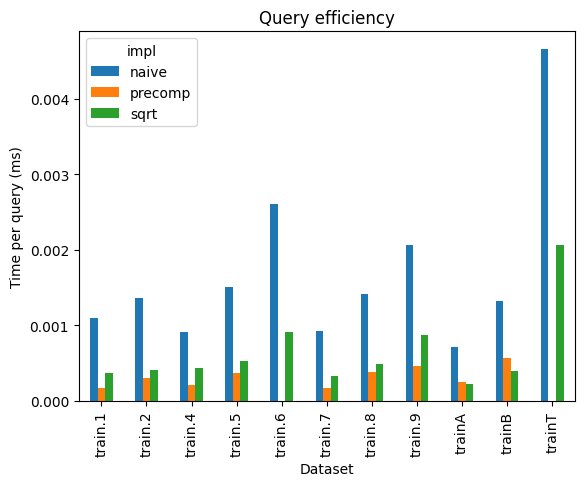

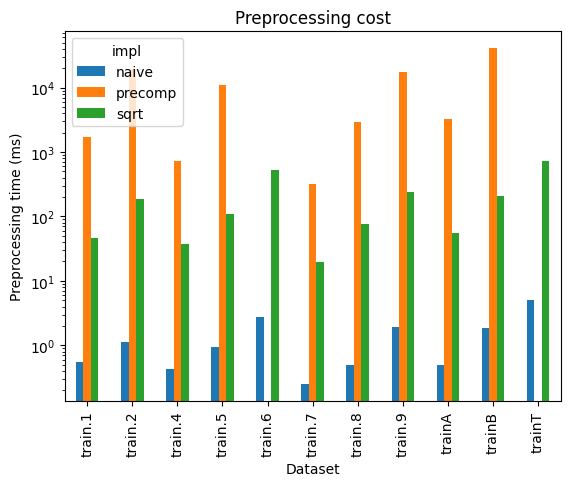

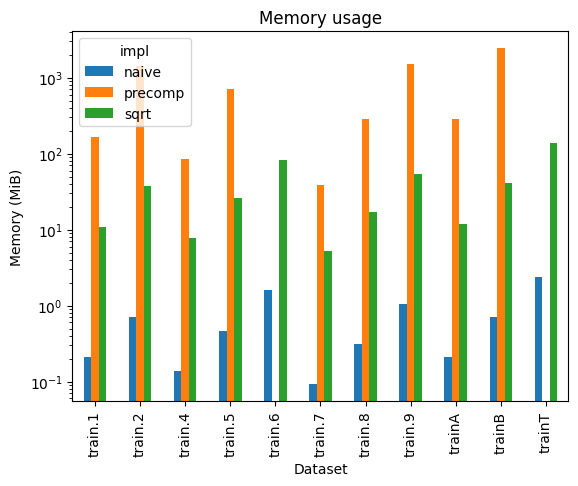

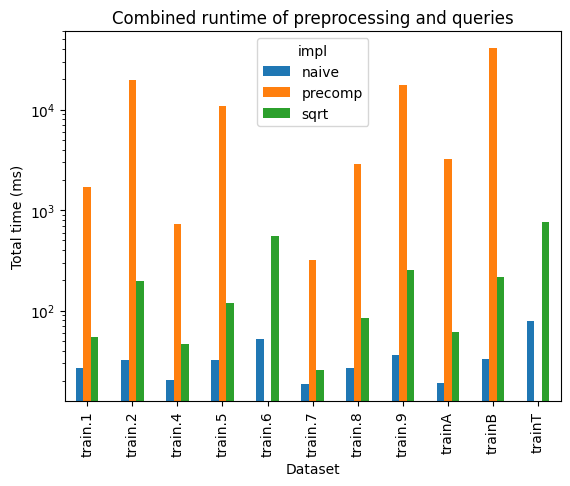

In [96]:
ax = summary.pivot(index="dataset", columns="impl", values="query_ms_per_query").plot(kind="bar")
plt.xlabel("Dataset")
plt.ylabel("Time per query (ms)")
plt.title("Query efficiency")
plt.show()

summary.pivot(index="dataset", columns="impl", values="build_mean_ms").plot(kind="bar")
plt.xlabel("Dataset")
plt.ylabel("Preprocessing time (ms)")
plt.yscale("log")
plt.title("Preprocessing cost")
plt.show()

summary.pivot(index="dataset", columns="impl", values="memory_mib").plot(kind="bar")
plt.xlabel("Dataset")
plt.ylabel("Memory (MiB)")
plt.yscale("log")
plt.title("Memory usage")
plt.show()

summary.pivot(index="dataset", columns="impl", values="total_mean_ms").plot(kind="bar")
plt.xlabel("Dataset")
plt.ylabel("Total time (ms)")
plt.yscale("log")
plt.title("Combined runtime of preprocessing and queries")
plt.show()

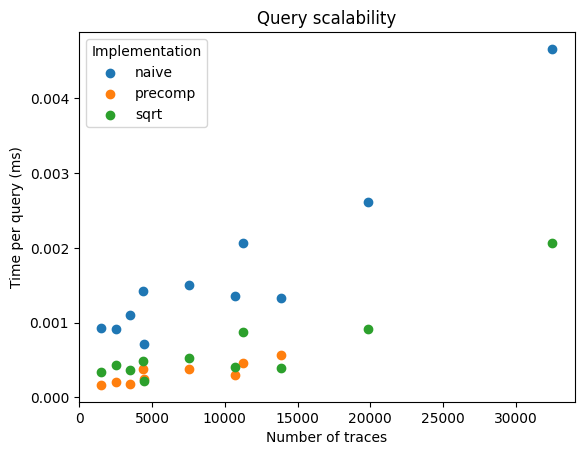

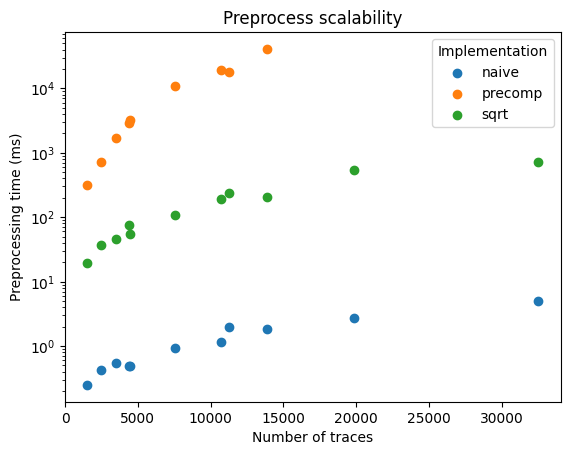

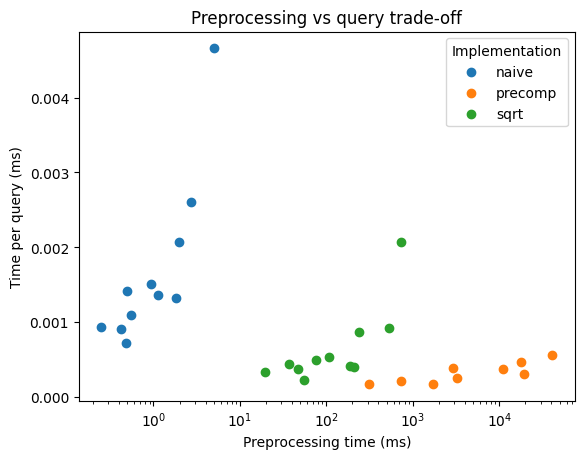

In [97]:
for impl in summary["impl"].unique():
    sub = summary[summary["impl"] == impl]
    plt.scatter(sub["num_traces"], sub["query_ms_per_query"], label=impl)
plt.xlabel("Number of traces")
plt.ylabel("Time per query (ms)")
plt.title("Query scalability")
plt.legend(title="Implementation")
plt.show()


for impl in summary["impl"].unique():
    sub = summary[summary["impl"] == impl]
    plt.scatter(sub["num_traces"], sub["build_mean_ms"], label=impl)
plt.xlabel("Number of traces")
plt.ylabel("Preprocessing time (ms)")
plt.yscale("log")
plt.title("Preprocess scalability")
plt.legend(title="Implementation")
plt.show()


for impl in summary["impl"].unique():
    sub = summary[summary["impl"] == impl]
    plt.scatter(sub["build_mean_ms"], sub["query_ms_per_query"], label=impl)

plt.xlabel("Preprocessing time (ms)")
plt.xscale("log")
plt.ylabel("Time per query (ms)")
plt.title("Preprocessing vs query trade-off")
plt.legend(title="Implementation")
plt.show()